:# 🧪 A/B Testing — Validasi Dataset Head 3
## SnapBudget · CC26-PSU098

**Tujuan:**
Membuktikan bahwa perbedaan pengeluaran antara mahasiswa
dengan label HEMAT dan BOROS benar-benar nyata secara statistik
— bukan hanya kebetulan dari data sintetis.

**Yang diuji:**
Semua 8 kategori pengeluaran: makanan, minuman, transportasi,
belanja, tagihan, hiburan, kesehatan, dan lain-lain.

**Metode:** Welch's Independent Two-Sample T-Test (p < 0.05)

## ⚙️ Import Library

Menyiapkan semua tools yang dibutuhkan untuk analisis statistik.

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Library siap!")

✅ Library siap!


## 📂 Load Dataset

Membaca dataset sintetis hasil generate dari notebook Head 3.
Dataset ini berisi 8.000 sampel kondisi keuangan mahasiswa
dengan label: HEMAT, AMAN, WASPADA, BOROS, dan DARURAT.

In [4]:
# Load dataset
df = pd.read_csv('head3_synthetic_dataset.csv')

print(f"✅ Dataset berhasil dimuat!")
print(f"   Jumlah data : {len(df):,} baris")
print(f"   Jumlah kolom: {len(df.columns)} kolom")

print(f"\nDistribusi label:")
print(df['overall_label_name'].value_counts())

# Kolom yang akan diuji (% budget terpakai per kategori)
CATEGORIES = ['makanan', 'minuman', 'transportasi', 'belanja',
              'tagihan', 'hiburan', 'kesehatan', 'lain_lain']

METRIC_COLS = [f'{cat}_pct_used' for cat in CATEGORIES]

print(f"\nKolom yang akan diuji:")
for col in METRIC_COLS:
    status = "✅" if col in df.columns else "❌ tidak ditemukan"
    print(f"  {status} {col}")

✅ Dataset berhasil dimuat!
   Jumlah data : 5,459 baris
   Jumlah kolom: 47 kolom

Distribusi label:
overall_label_name
AMAN       1948
WASPADA    1163
DARURAT     971
HEMAT       777
BOROS       599
Name: count, dtype: int64

Kolom yang akan diuji:
  ✅ makanan_pct_used
  ✅ minuman_pct_used
  ✅ transportasi_pct_used
  ✅ belanja_pct_used
  ✅ tagihan_pct_used
  ✅ hiburan_pct_used
  ✅ kesehatan_pct_used
  ✅ lain_lain_pct_used


## 🧪 A/B Testing: HEMAT vs BOROS

**Apa yang kita lakukan?**
Membandingkan rata-rata % budget yang dipakai antara:
- **Group A** → mahasiswa dengan label HEMAT
- **Group B** → mahasiswa dengan label BOROS

Untuk setiap kategori pengeluaran (makanan, minuman, dll).

**Hipotesis:**
- H0 (Hipotesis Nol)    : Tidak ada perbedaan antara HEMAT dan BOROS
- H1 (Hipotesis Alternatif): Ada perbedaan antara HEMAT dan BOROS

**Keputusan:**
Jika p-value < 0.05 → tolak H0 → perbedaan NYATA secara statistik ✅
Jika p-value ≥ 0.05 → gagal tolak H0 → perbedaan tidak signifikan ❌

**Mengapa Welch's T-Test?**
Karena kita tidak mengasumsikan kedua kelompok punya
variasi (spread) data yang sama — lebih aman dan akurat.

In [5]:
GROUP_A = 'HEMAT'
GROUP_B = 'BOROS'
ALPHA   = 0.05

print("=" * 68)
print(f"  A/B TESTING: {GROUP_A} (Group A)  vs  {GROUP_B} (Group B)")
print("=" * 68)
print(f"  {'Kategori':<16} {'Rata² A':>9} {'Rata² B':>9} "
      f"{'T-stat':>8} {'P-value':>12} {'Hasil':>6}")
print("-" * 68)

hasil_ab = {}

for col in METRIC_COLS:
    if col not in df.columns:
        continue

    cat   = col.replace('_pct_used', '')
    ga    = df[df['overall_label_name'] == GROUP_A][col].dropna()
    gb    = df[df['overall_label_name'] == GROUP_B][col].dropna()

    t_stat, p_val = stats.ttest_ind(ga, gb, equal_var=False)
    signifikan    = p_val < ALPHA
    hasil         = "✅ BEDA" if signifikan else "❌ SAMA"

    hasil_ab[cat] = {
        'mean_a'    : ga.mean(),
        'mean_b'    : gb.mean(),
        't_stat'    : t_stat,
        'p_value'   : p_val,
        'signifikan': signifikan,
        'n_a'       : len(ga),
        'n_b'       : len(gb),
    }

    print(f"  {cat:<16} {ga.mean():>9.3f} {gb.mean():>9.3f} "
          f"{t_stat:>8.2f} {p_val:>12.4e} {hasil:>6}")

print("-" * 68)
n_sig = sum(1 for v in hasil_ab.values() if v['signifikan'])
print(f"\n  Signifikan: {n_sig}/{len(hasil_ab)} kategori (p < {ALPHA})")

# Ringkasan grup
ga_all = df[df['overall_label_name'] == GROUP_A]
gb_all = df[df['overall_label_name'] == GROUP_B]
print(f"\n  Jumlah sampel {GROUP_A}: {len(ga_all):,}")
print(f"  Jumlah sampel {GROUP_B}: {len(gb_all):,}")

  A/B TESTING: HEMAT (Group A)  vs  BOROS (Group B)
  Kategori           Rata² A   Rata² B   T-stat      P-value  Hasil
--------------------------------------------------------------------
  makanan              0.197     0.596   -32.33  3.3402e-143 ✅ BEDA
  minuman              0.199     0.593   -31.52  4.2585e-138 ✅ BEDA
  transportasi         0.200     0.592   -31.56  1.1924e-138 ✅ BEDA
  belanja              0.201     0.599   -30.67  4.2505e-133 ✅ BEDA
  tagihan              0.357     1.068   -63.79  2.5133e-308 ✅ BEDA
  hiburan              0.236     0.703   -27.63  4.8291e-115 ✅ BEDA
  kesehatan            0.201     0.592   -30.21  1.3889e-130 ✅ BEDA
  lain_lain            0.200     0.593   -30.34  9.0968e-131 ✅ BEDA
--------------------------------------------------------------------

  Signifikan: 8/8 kategori (p < 0.05)

  Jumlah sampel HEMAT: 777
  Jumlah sampel BOROS: 599


## 📊 Visualisasi Hasil

Menampilkan perbandingan distribusi pengeluaran antara
kelompok HEMAT dan BOROS secara visual untuk semua 8 kategori.

**Cara membaca grafik:**
- Kurva HIJAU → kelompok HEMAT
- Kurva MERAH → kelompok BOROS
- Semakin sedikit overlap → semakin besar perbedaannya
- Nilai p di judul tiap grafik → makin kecil makin signifikan

/tmp/ipykernel_7346/3279808679.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7346/3279808679.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('ab_testing_hasil.png', dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


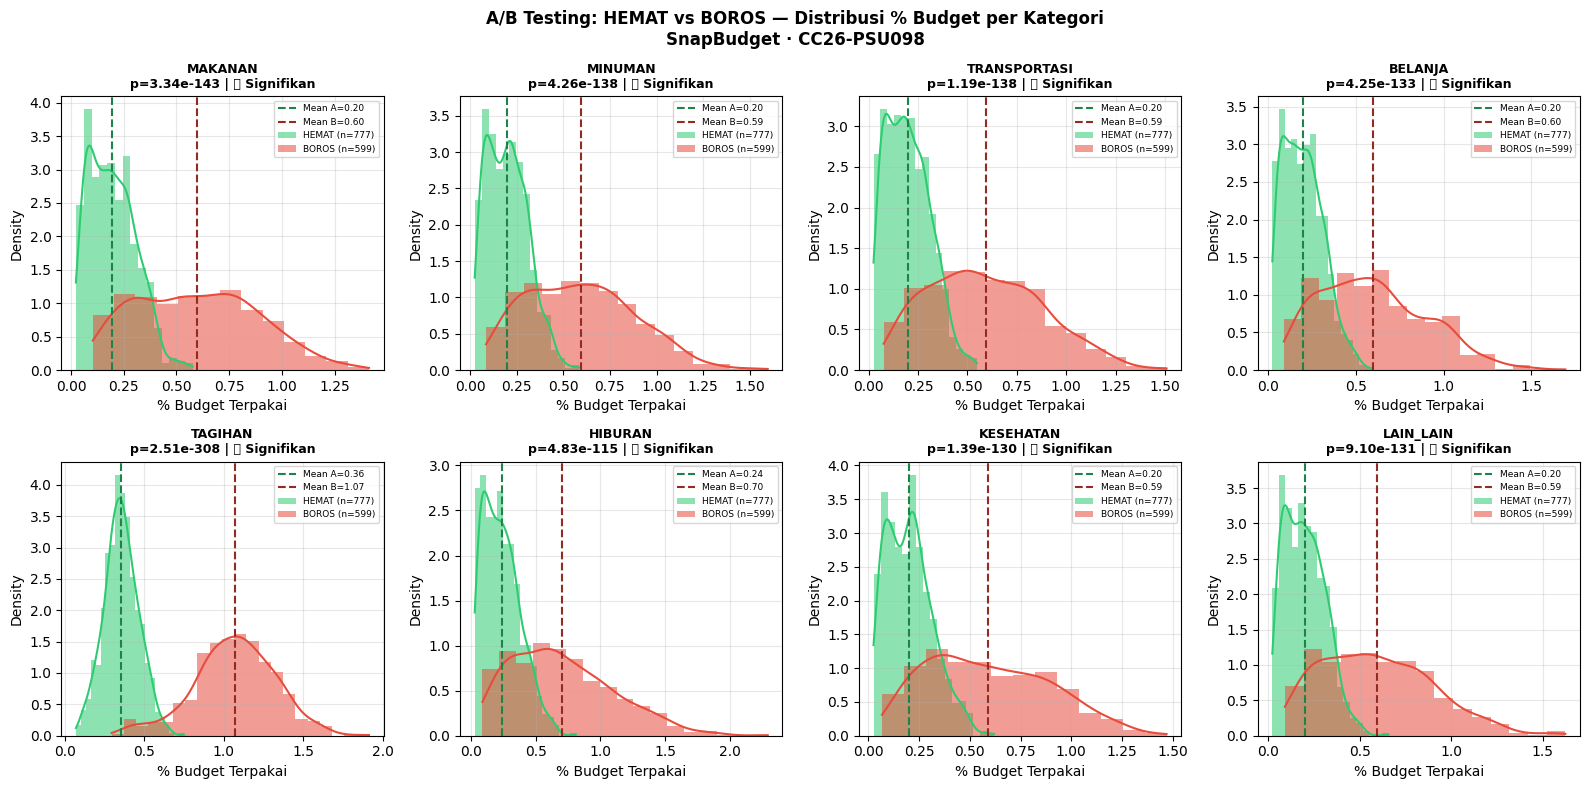

✅ Grafik tersimpan: ab_testing_hasil.png


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(METRIC_COLS):
    if col not in df.columns:
        continue

    ax  = axes[i]
    cat = col.replace('_pct_used', '')
    ga  = df[df['overall_label_name'] == GROUP_A][col].dropna()
    gb  = df[df['overall_label_name'] == GROUP_B][col].dropna()
    info = hasil_ab.get(cat, {})
    p    = info.get('p_value', 1)
    sig  = "✅ Signifikan" if info.get('signifikan') else "❌ Tidak Signifikan"

    # Distribusi
    sns.histplot(ga, ax=ax, color='#2ECC71', label=f'HEMAT (n={len(ga)})',
                 kde=True, stat='density', linewidth=0, alpha=0.55)
    sns.histplot(gb, ax=ax, color='#E74C3C', label=f'BOROS (n={len(gb)})',
                 kde=True, stat='density', linewidth=0, alpha=0.55)

    # Garis rata-rata
    ax.axvline(ga.mean(), color='#1D8348', linestyle='--',
               linewidth=1.5, label=f'Mean A={ga.mean():.2f}')
    ax.axvline(gb.mean(), color='#922B21', linestyle='--',
               linewidth=1.5, label=f'Mean B={gb.mean():.2f}')

    ax.set_title(f'{cat.upper()}\np={p:.2e} | {sig}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('% Budget Terpakai')
    ax.set_ylabel('Density')
    ax.legend(fontsize=6.5)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'A/B Testing: HEMAT vs BOROS — Distribusi % Budget per Kategori\n'
    f'SnapBudget · CC26-PSU098',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_testing_hasil.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Grafik tersimpan: ab_testing_hasil.png")

## 📦 Boxplot Perbandingan

Boxplot memperlihatkan persebaran nilai lebih jelas:
- **Kotak** → 50% data berada di rentang ini (IQR)
- **Garis tengah** → nilai median
- **Titik-titik** → data outlier (nilai ekstrem)

Jika kotak HEMAT dan BOROS tidak tumpang tindih →
perbedaan semakin nyata.

/tmp/ipykernel_7346/3237226501.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='overall_label_name', y=col,
/tmp/ipykernel_7346/3237226501.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='overall_label_name', y=col,
/tmp/ipykernel_7346/3237226501.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='overall_label_name', y=col,
/tmp/ipykernel_7346/3237226501.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

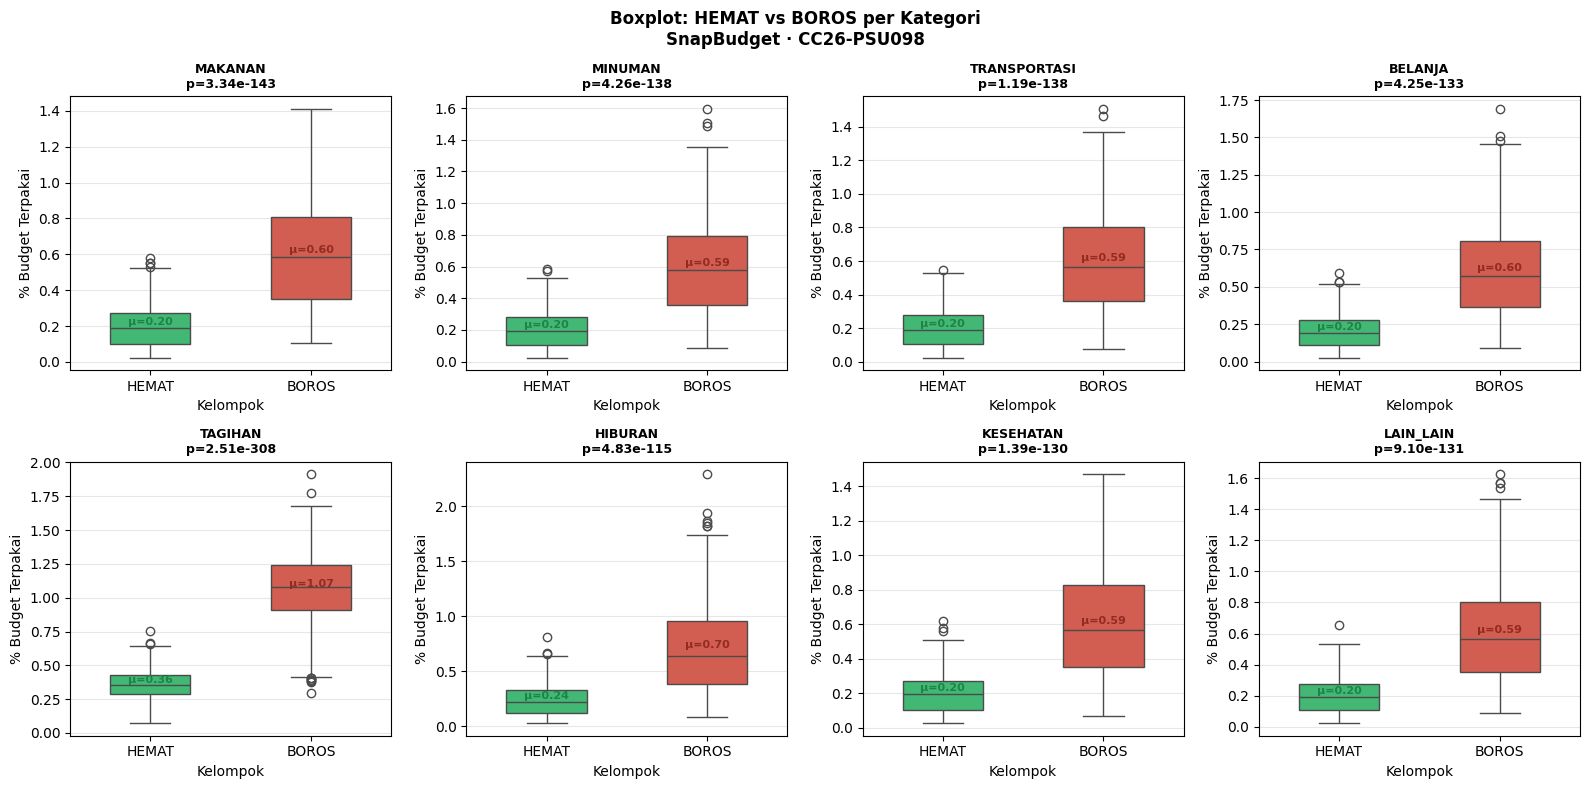

✅ Grafik tersimpan: ab_testing_boxplot.png


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(METRIC_COLS):
    if col not in df.columns:
        continue

    ax  = axes[i]
    cat = col.replace('_pct_used', '')

    plot_df = df[df['overall_label_name'].isin([GROUP_A, GROUP_B])][
        ['overall_label_name', col]].dropna()

    sns.boxplot(data=plot_df, x='overall_label_name', y=col,
                palette={GROUP_A: '#2ECC71', GROUP_B: '#E74C3C'},
                order=[GROUP_A, GROUP_B], ax=ax, width=0.5)

    info = hasil_ab.get(cat, {})
    p    = info.get('p_value', 1)
    ma   = info.get('mean_a', 0)
    mb   = info.get('mean_b', 0)

    ax.set_title(f'{cat.upper()}\np={p:.2e}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Kelompok')
    ax.set_ylabel('% Budget Terpakai')
    ax.grid(True, alpha=0.3, axis='y')

    # Tambah anotasi mean
    ax.text(0, ma + 0.01, f'μ={ma:.2f}',
            ha='center', fontsize=8, color='#1D8348', fontweight='bold')
    ax.text(1, mb + 0.01, f'μ={mb:.2f}',
            ha='center', fontsize=8, color='#922B21', fontweight='bold')

plt.suptitle(
    f'Boxplot: HEMAT vs BOROS per Kategori\nSnapBudget · CC26-PSU098',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_testing_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Grafik tersimpan: ab_testing_boxplot.png")

## ✅ Kesimpulan

Merangkum seluruh hasil A/B testing secara otomatis dan
memberikan kesimpulan apakah dataset Head 3 valid untuk
digunakan melatih model klasifikasi SnapBudget.

In [8]:
print("=" * 60)
print("  KESIMPULAN A/B TESTING — SnapBudget Head 3")
print("=" * 60)

n_sig   = sum(1 for v in hasil_ab.values() if v['signifikan'])
n_total = len(hasil_ab)

print(f"\n  Perbandingan  : {GROUP_A} vs {GROUP_B}")
print(f"  Alpha         : {ALPHA} (5%)")
print(f"  Kategori diuji: {n_total}")
print(f"  Signifikan    : {n_sig}/{n_total} kategori\n")

print(f"  Detail hasil:")
for cat, info in hasil_ab.items():
    status = "✅ SIGNIFIKAN    " if info['signifikan'] else "❌ Tidak signifikan"
    selisih = abs(info['mean_b'] - info['mean_a'])
    print(f"  {cat:<15} → {status} "
          f"| selisih rata²: {selisih:.3f}")

print()
if n_sig == n_total:
    print("  🎯 KESIMPULAN AKHIR:")
    print(f"  Semua {n_total} kategori menunjukkan perbedaan yang")
    print(f"  signifikan secara statistik antara kelompok {GROUP_A}")
    print(f"  dan {GROUP_B} (p < 0.05).")
    print()
    print("  ✅ Dataset Head 3 VALID dan layak digunakan untuk")
    print("     melatih model klasifikasi status keuangan SnapBudget.")
elif n_sig >= n_total * 0.75:
    print("  ⚠️  Sebagian besar kategori signifikan.")
    print(f"  Dataset cukup valid ({n_sig}/{n_total} kategori).")
else:
    print("  ❌ Banyak kategori tidak signifikan.")
    print("     Tinjau ulang proses generate dataset.")

print()
print("  📁 File yang dihasilkan:")
print("     ab_testing_hasil.png   → grafik distribusi")
print("     ab_testing_boxplot.png → grafik boxplot")
print("=" * 60)

  KESIMPULAN A/B TESTING — SnapBudget Head 3

  Perbandingan  : HEMAT vs BOROS
  Alpha         : 0.05 (5%)
  Kategori diuji: 8
  Signifikan    : 8/8 kategori

  Detail hasil:
  makanan         → ✅ SIGNIFIKAN     | selisih rata²: 0.400
  minuman         → ✅ SIGNIFIKAN     | selisih rata²: 0.393
  transportasi    → ✅ SIGNIFIKAN     | selisih rata²: 0.392
  belanja         → ✅ SIGNIFIKAN     | selisih rata²: 0.397
  tagihan         → ✅ SIGNIFIKAN     | selisih rata²: 0.711
  hiburan         → ✅ SIGNIFIKAN     | selisih rata²: 0.467
  kesehatan       → ✅ SIGNIFIKAN     | selisih rata²: 0.391
  lain_lain       → ✅ SIGNIFIKAN     | selisih rata²: 0.393

  🎯 KESIMPULAN AKHIR:
  Semua 8 kategori menunjukkan perbedaan yang
  signifikan secara statistik antara kelompok HEMAT
  dan BOROS (p < 0.05).

  ✅ Dataset Head 3 VALID dan layak digunakan untuk
     melatih model klasifikasi status keuangan SnapBudget.

  📁 File yang dihasilkan:
     ab_testing_hasil.png   → grafik distribusi
     ab_testin